<a href="https://colab.research.google.com/github/Kirthiga19/Kirthiga19/blob/main/SmartInventoryTrackingSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving weapons-sales dataset.csv to weapons-sales dataset.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("weapons-sales dataset.csv")
df.head()

,Rank (2021),Rank (2020),Company (c),Notes (2021),Country (d),Arms Sales (2021),Arms sales (2020),Total Sales (2021),Arms sales as a % of total sales (2021),Arms sales 2020 (constant 2021 prices) note (e)
0,1,1,Lockheed Martin Corp.,NaN,United States,60340.0,58210.0,67044,90,60704.0
1,2,2,Raytheon Technologies,NaN,United States,41850.0,36780.0,64388,65,38356.0
2,3,3,Boeing,NaN,United States,33420.0,32740.0,62286,54,34143.0
3,4,4,Northrop Grumman Corp.,NaN,United States,29880.0,30420.0,35667,84,31723.0
4,5,5,General Dynamics Corp.,NaN,United States,26390.0,25840.0,38469,69,26947.0


In [4]:
df = df.dropna()
df.shape

(24, 10)

In [8]:
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'Company (c)': 'Branch',
    'Arms sales (2020)': 'Previous_Stock',
    'Arms Sales (2021)': 'Current_Stock'
})

df[['Branch', 'Previous_Stock', 'Current_Stock']].head()

,Branch,Previous_Stock,Current_Stock
8,CASC,16880.0,19100.0
9,CETC,14610.0,14990.0
10,CASIC,11870.0,14520.0
13,CSSC,9370.0,11130.0
14,Airbus,11990.0,10850.0


In [9]:
X = df[['Previous_Stock']]
y = df['Current_Stock']

In [10]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [11]:
predicted = model.predict([[50]])
print("Predicted Stock for input 50:", predicted[0])

Predicted Stock for input 50: 8.70330829510251


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
df['Low_Stock'] = df['Current_Stock'] < 20

low_stock = df[df['Low_Stock']]

low_stock[['Branch', 'Current_Stock']]

,Branch,Current_Stock


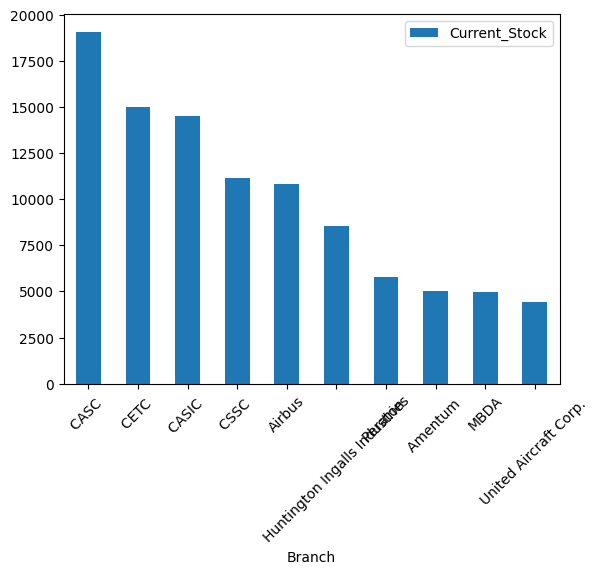

In [13]:
df.sort_values('Current_Stock', ascending=False).head(10).plot(
    x='Branch',
    y='Current_Stock',
    kind='bar'
)

plt.xticks(rotation=45)
plt.show()

In [14]:
from sklearn.metrics import r2_score

preds = model.predict(X)
print("Model Accuracy:", r2_score(y, preds))

Model Accuracy: 0.9813075070729919
